# Netflix User Churn Analysis & Prediction

**Objective:** Analyze Netflix user data to identify churn patterns and build classification models to predict which users are likely to churn.

**Approach:**
1. Data Loading & Exploration
2. Feature Engineering
3. Exploratory Data Analysis (EDA)
4. Data Preprocessing
5. Model Training & Evaluation
6. Feature Importance Analysis
7. Conclusion

---

## 1. Import Libraries

In [ ]:
# Core libraries
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid', palette='Set2')

# Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Evaluation
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    roc_auc_score, roc_curve, f1_score, precision_score, recall_score
)

print("✅ All libraries imported successfully.")

✅ All libraries imported successfully.


## 2. Load & Explore Dataset

In [ ]:
# Load dataset
df = pd.read_csv('../data/netflix_users.csv')

print(f"Dataset Shape: {df.shape}")
print(f"Total Users: {df.shape[0]:,}")
print(f"Total Features: {df.shape[1]}")
print()
df.head(10)

Dataset Shape: (25000, 8)
Total Users: 25,000
Total Features: 8



,User_ID,Name,Age,Country,Subscription_Type,Watch_Time_Hours,Favorite_Genre,Last_Login
0,1,James Martinez,18,France,Premium,80.26,Drama,2024-05-12
1,2,John Miller,23,USA,Premium,321.75,Sci-Fi,2025-02-05
2,3,Emma Davis,60,UK,Basic,35.89,Comedy,2025-01-24
3,4,Emma Miller,44,USA,Premium,261.56,Documentary,2024-03-25
4,5,Jane Smith,68,USA,Standard,909.30,Drama,2025-01-14
5,6,David Johnson,21,USA,Standard,615.93,Romance,2025-02-03
6,7,John Hernandez,57,Canada,Standard,755.47,Romance,2025-01-05
7,8,Katie Hernandez,68,USA,Standard,145.23,Sci-Fi,2024-10-30
8,9,James Williams,39,UK,Basic,950.14,Action,2024-04-16
9,10,Alex Davis,55,Mexico,Standard,696.66,Horror,2024-07-03


In [ ]:
# Data types and info
print("=" * 50)
print("DATA TYPES")
print("=" * 50)
print(df.dtypes)
print()
print("=" * 50)
print("MISSING VALUES")
print("=" * 50)
print(df.isnull().sum())
print()
print("=" * 50)
print("STATISTICAL SUMMARY")
print("=" * 50)
df.describe()

DATA TYPES
User_ID                int64
Name                     str
Age                    int64
Country                  str
Subscription_Type        str
Watch_Time_Hours     float64
Favorite_Genre           str
Last_Login               str
dtype: object

MISSING VALUES
User_ID              0
Name                 0
Age                  0
Country              0
Subscription_Type    0
Watch_Time_Hours     0
Favorite_Genre       0
Last_Login           0
dtype: int64

STATISTICAL SUMMARY


,User_ID,Age,Watch_Time_Hours
count,25000.000000,25000.000000,25000.000000
mean,12500.500000,46.482880,500.468858
std,7217.022701,19.594861,286.381815
min,1.000000,13.000000,0.120000
25%,6250.750000,29.000000,256.567500
50%,12500.500000,46.000000,501.505000
75%,18750.250000,63.000000,745.732500
max,25000.000000,80.000000,999.990000


In [ ]:
# Categorical columns summary
print("=" * 50)
print("CATEGORICAL FEATURES")
print("=" * 50)
for col in ['Country', 'Subscription_Type', 'Favorite_Genre']:
    print(f"\n{col} ({df[col].nunique()} unique):")
    print(df[col].value_counts())

CATEGORICAL FEATURES

Country (10 unique):
Country
UK           2592
Germany      2547
India        2505
USA          2503
Brazil       2503
Mexico       2493
Canada       2490
France       2473
Japan        2457
Australia    2437
Name: count, dtype: int64

Subscription_Type (3 unique):
Subscription_Type
Premium     8402
Basic       8356
Standard    8242
Name: count, dtype: int64

Favorite_Genre (7 unique):
Favorite_Genre
Horror         3654
Documentary    3636
Action         3589
Romance        3572
Comedy         3561
Drama          3533
Sci-Fi         3455
Name: count, dtype: int64


## 3. Feature Engineering — Churn Label Creation
Create a binary churn label based on **Days Since Last Login** (threshold: 90 days).

In [ ]:
# Convert Last_Login to datetime
df['Last_Login'] = pd.to_datetime(df['Last_Login'])

# Reference date: the most recent login in the dataset
reference_date = df['Last_Login'].max()
print(f"Reference Date (most recent login): {reference_date.date()}")

# Calculate days since last login
df['Days_Since_Login'] = (reference_date - df['Last_Login']).dt.days

# Define Churn: 1 = Churned (inactive > 90 days), 0 = Active
df['Churned'] = (df['Days_Since_Login'] > 90).astype(int)

print(f"\nChurn Distribution:")
print(df['Churned'].value_counts())
print(f"\nChurn Rate: {df['Churned'].mean() * 100:.2f}%")

Reference Date (most recent login): 2025-03-08

Churn Distribution:
Churned
1    18681
0     6319
Name: count, dtype: int64

Churn Rate: 74.72%


## 4. Exploratory Data Analysis (EDA)

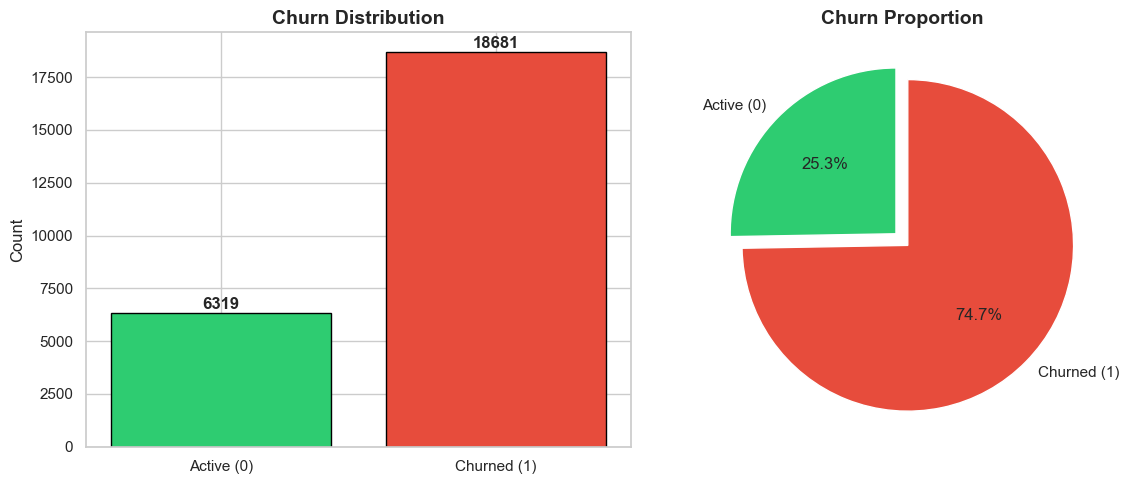

In [ ]:
# 4.1 — Churn Distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot — use .sort_index() to ensure 0=Active, 1=Churned order
churn_counts = df['Churned'].value_counts().sort_index()
labels = ['Active (0)', 'Churned (1)']
colors = ['#2ecc71', '#e74c3c']

axes[0].bar(labels, churn_counts.values, color=colors, edgecolor='black')
axes[0].set_title('Churn Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 200, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(churn_counts.values, labels=labels, autopct='%1.1f%%',
            colors=colors, startangle=90, explode=(0.05, 0.05))
axes[1].set_title('Churn Proportion', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

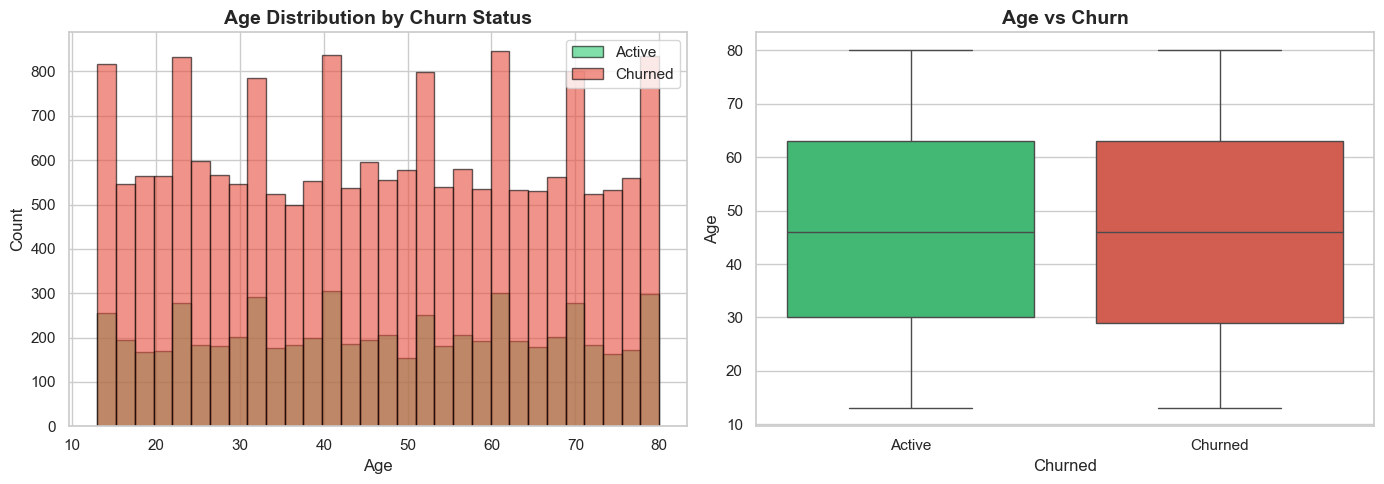

In [13]:
# 4.2 — Age Distribution by Churn Status
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
for label, color in zip([0, 1], ['#2ecc71', '#e74c3c']):
    subset = df[df['Churned'] == label]
    axes[0].hist(subset['Age'], bins=30, alpha=0.6, color=color,
                 label=f"{'Active' if label == 0 else 'Churned'}", edgecolor='black')
axes[0].set_title('Age Distribution by Churn Status', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')
axes[0].legend()

# Box plot
sns.boxplot(x='Churned', y='Age', data=df, ax=axes[1], palette=['#2ecc71', '#e74c3c'])
axes[1].set_title('Age vs Churn', fontsize=14, fontweight='bold')
axes[1].set_xticklabels(['Active', 'Churned'])

plt.tight_layout()
plt.show()

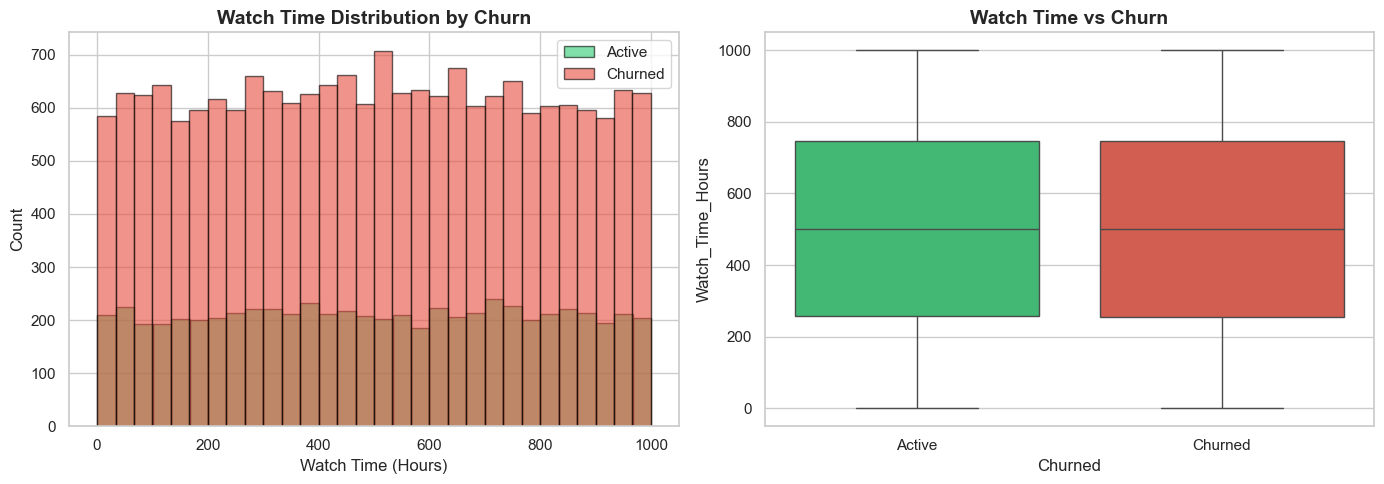

In [14]:
# 4.3 — Watch Time Distribution by Churn Status
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for label, color in zip([0, 1], ['#2ecc71', '#e74c3c']):
    subset = df[df['Churned'] == label]
    axes[0].hist(subset['Watch_Time_Hours'], bins=30, alpha=0.6, color=color,
                 label=f"{'Active' if label == 0 else 'Churned'}", edgecolor='black')
axes[0].set_title('Watch Time Distribution by Churn', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Watch Time (Hours)')
axes[0].set_ylabel('Count')
axes[0].legend()

sns.boxplot(x='Churned', y='Watch_Time_Hours', data=df, ax=axes[1], palette=['#2ecc71', '#e74c3c'])
axes[1].set_title('Watch Time vs Churn', fontsize=14, fontweight='bold')
axes[1].set_xticklabels(['Active', 'Churned'])

plt.tight_layout()
plt.show()

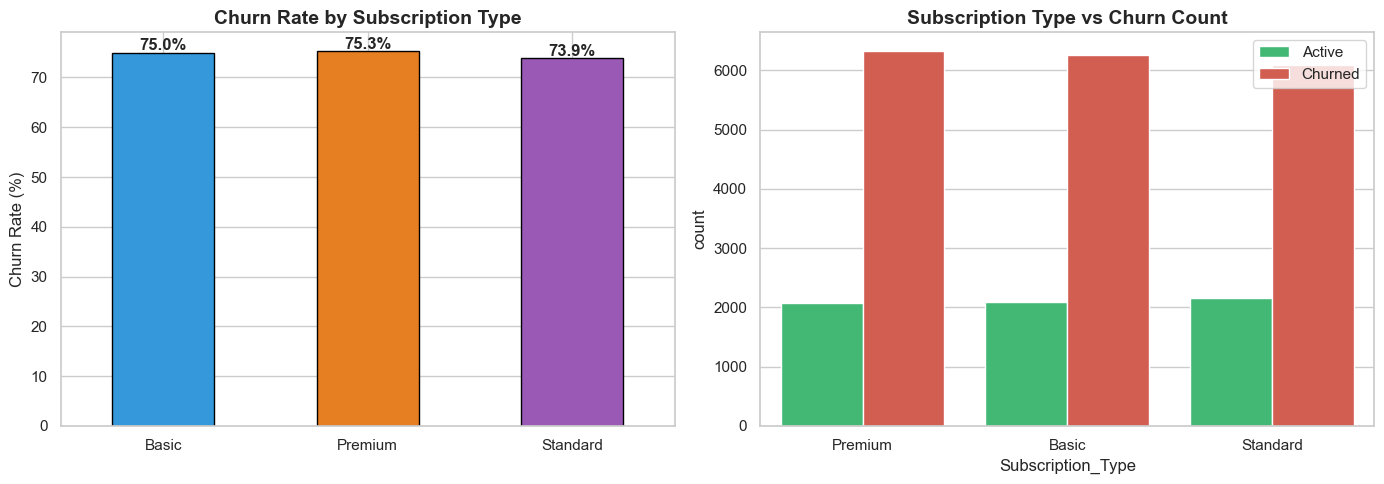

In [15]:
# 4.4 — Churn Rate by Subscription Type
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Churn rate by subscription
churn_by_sub = df.groupby('Subscription_Type')['Churned'].mean() * 100
churn_by_sub.plot(kind='bar', ax=axes[0], color=['#3498db', '#e67e22', '#9b59b6'], edgecolor='black')
axes[0].set_title('Churn Rate by Subscription Type', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].set_xlabel('')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
for i, v in enumerate(churn_by_sub.values):
    axes[0].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

# Count by subscription & churn
sns.countplot(x='Subscription_Type', hue='Churned', data=df, ax=axes[1],
              palette=['#2ecc71', '#e74c3c'])
axes[1].set_title('Subscription Type vs Churn Count', fontsize=14, fontweight='bold')
axes[1].legend(['Active', 'Churned'])

plt.tight_layout()
plt.show()

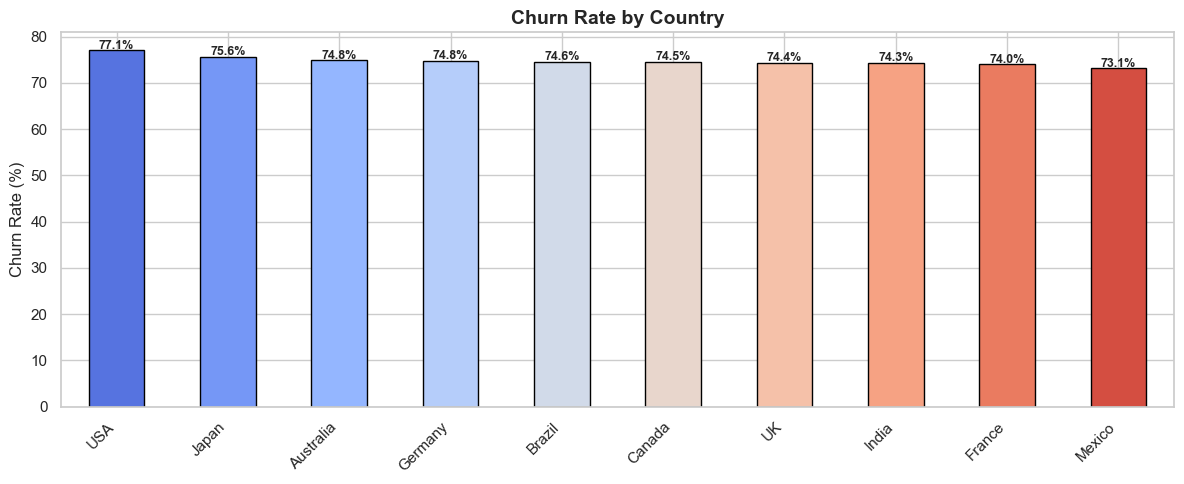

In [16]:
# 4.5 — Churn Rate by Country
fig, ax = plt.subplots(figsize=(12, 5))

churn_by_country = df.groupby('Country')['Churned'].mean().sort_values(ascending=False) * 100
churn_by_country.plot(kind='bar', ax=ax, color=sns.color_palette('coolwarm', len(churn_by_country)),
                      edgecolor='black')
ax.set_title('Churn Rate by Country', fontsize=14, fontweight='bold')
ax.set_ylabel('Churn Rate (%)')
ax.set_xlabel('')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
for i, v in enumerate(churn_by_country.values):
    ax.text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

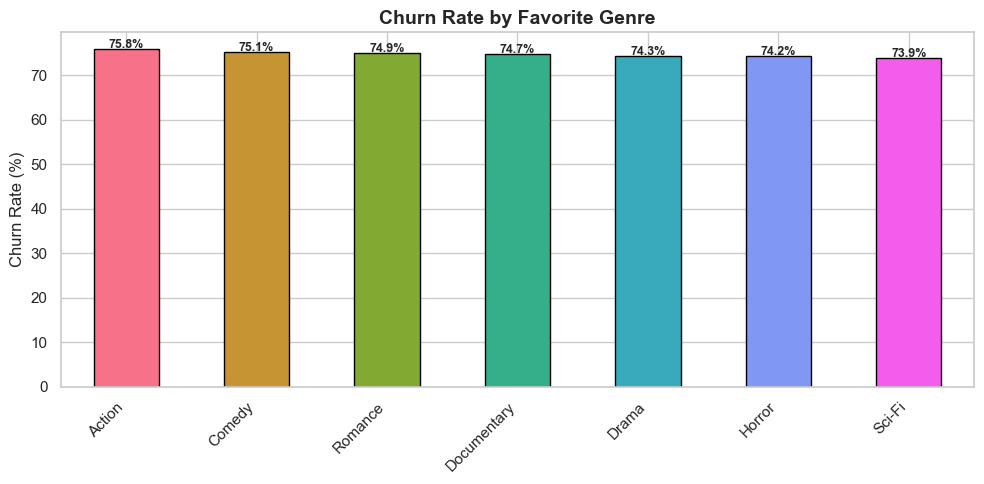

In [17]:
# 4.6 — Churn Rate by Favorite Genre
fig, ax = plt.subplots(figsize=(10, 5))

churn_by_genre = df.groupby('Favorite_Genre')['Churned'].mean().sort_values(ascending=False) * 100
churn_by_genre.plot(kind='bar', ax=ax, color=sns.color_palette('husl', len(churn_by_genre)),
                    edgecolor='black')
ax.set_title('Churn Rate by Favorite Genre', fontsize=14, fontweight='bold')
ax.set_ylabel('Churn Rate (%)')
ax.set_xlabel('')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
for i, v in enumerate(churn_by_genre.values):
    ax.text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

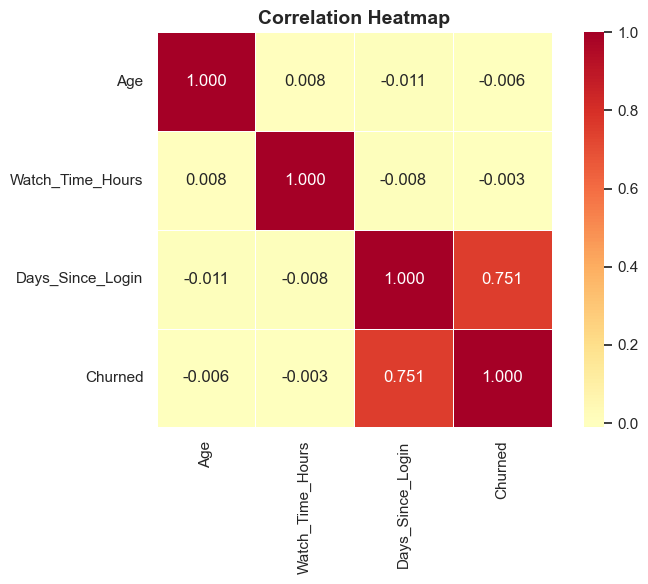

In [18]:
# 4.7 — Correlation Heatmap (Numerical Features)
fig, ax = plt.subplots(figsize=(8, 6))

numerical_cols = df[['Age', 'Watch_Time_Hours', 'Days_Since_Login', 'Churned']]
corr_matrix = numerical_cols.corr()

sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn_r', center=0, fmt='.3f',
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Correlation Heatmap', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## 5. Data Preprocessing
Prepare the data for modeling: drop non-predictive columns, encode categorical features, split into train/test, and scale features.

In [19]:
# 5.1 — Drop non-predictive columns
drop_cols = ['User_ID', 'Name', 'Last_Login', 'Days_Since_Login']
df_model = df.drop(columns=drop_cols)

print(f"Columns for modeling: {list(df_model.columns)}")
print(f"Shape: {df_model.shape}")
df_model.head()

Columns for modeling: ['Age', 'Country', 'Subscription_Type', 'Watch_Time_Hours', 'Favorite_Genre', 'Churned']
Shape: (25000, 6)


,Age,Country,Subscription_Type,Watch_Time_Hours,Favorite_Genre,Churned
0,18,France,Premium,80.26,Drama,1
1,23,USA,Premium,321.75,Sci-Fi,0
2,60,UK,Basic,35.89,Comedy,0
3,44,USA,Premium,261.56,Documentary,1
4,68,USA,Standard,909.30,Drama,0


In [20]:
# 5.2 — Encode Categorical Features
label_encoders = {}
categorical_cols = ['Country', 'Subscription_Type', 'Favorite_Genre']

for col in categorical_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])
    label_encoders[col] = le
    print(f"{col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

print("\nEncoded DataFrame:")
df_model.head()

Country: {'Australia': np.int64(0), 'Brazil': np.int64(1), 'Canada': np.int64(2), 'France': np.int64(3), 'Germany': np.int64(4), 'India': np.int64(5), 'Japan': np.int64(6), 'Mexico': np.int64(7), 'UK': np.int64(8), 'USA': np.int64(9)}
Subscription_Type: {'Basic': np.int64(0), 'Premium': np.int64(1), 'Standard': np.int64(2)}
Favorite_Genre: {'Action': np.int64(0), 'Comedy': np.int64(1), 'Documentary': np.int64(2), 'Drama': np.int64(3), 'Horror': np.int64(4), 'Romance': np.int64(5), 'Sci-Fi': np.int64(6)}

Encoded DataFrame:


,Age,Country,Subscription_Type,Watch_Time_Hours,Favorite_Genre,Churned
0,18,3,1,80.26,3,1
1,23,9,1,321.75,6,0
2,60,8,0,35.89,1,0
3,44,9,1,261.56,2,1
4,68,9,2,909.30,3,0


In [21]:
# 5.3 — Train-Test Split
X = df_model.drop(columns=['Churned'])
y = df_model['Churned']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]:,} samples")
print(f"Test set:     {X_test.shape[0]:,} samples")
print(f"\nTarget distribution in train set:")
print(y_train.value_counts(normalize=True).apply(lambda x: f"{x:.2%}"))

Training set: 20,000 samples
Test set:     5,000 samples

Target distribution in train set:
Churned
1    74.72%
0    25.27%
Name: proportion, dtype: str


In [22]:
# 5.4 — Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Features scaled successfully.")
print(f"Feature names: {list(X.columns)}")

✅ Features scaled successfully.
Feature names: ['Age', 'Country', 'Subscription_Type', 'Watch_Time_Hours', 'Favorite_Genre']


## 6. Model Training
Train three classification models: **Logistic Regression**, **Random Forest**, and **Gradient Boosting**.

In [23]:
# 6.1 — Define and Train Models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, random_state=42)
}

results = {}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train_scaled, y_train)
    
    # Predictions
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    # Cross-validation score
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy')
    
    # Store results
    results[name] = {
        'model': model,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_pred_proba),
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std()
    }
    
    print(f"  ✅ Accuracy: {results[name]['accuracy']:.4f} | "
          f"F1: {results[name]['f1']:.4f} | "
          f"ROC-AUC: {results[name]['roc_auc']:.4f} | "
          f"CV: {results[name]['cv_mean']:.4f} ± {results[name]['cv_std']:.4f}")
    print()

Training Logistic Regression...
  ✅ Accuracy: 0.7472 | F1: 0.8553 | ROC-AUC: 0.4843 | CV: 0.7472 ± 0.0000

Training Random Forest...
  ✅ Accuracy: 0.7140 | F1: 0.8297 | ROC-AUC: 0.4990 | CV: 0.7162 ± 0.0018

Training Gradient Boosting...
  ✅ Accuracy: 0.7464 | F1: 0.8547 | ROC-AUC: 0.4925 | CV: 0.7460 ± 0.0009



## 7. Model Evaluation & Comparison

In [24]:
# 7.1 — Classification Reports
for name, res in results.items():
    print("=" * 60)
    print(f"  {name}")
    print("=" * 60)
    print(classification_report(y_test, res['y_pred'], target_names=['Active', 'Churned']))
    print()

  Logistic Regression
              precision    recall  f1-score   support

      Active       0.00      0.00      0.00      1264
     Churned       0.75      1.00      0.86      3736

    accuracy                           0.75      5000
   macro avg       0.37      0.50      0.43      5000
weighted avg       0.56      0.75      0.64      5000


  Random Forest
              precision    recall  f1-score   support

      Active       0.25      0.07      0.11      1264
     Churned       0.75      0.93      0.83      3736

    accuracy                           0.71      5000
   macro avg       0.50      0.50      0.47      5000
weighted avg       0.62      0.71      0.65      5000


  Gradient Boosting
              precision    recall  f1-score   support

      Active       0.33      0.00      0.01      1264
     Churned       0.75      1.00      0.85      3736

    accuracy                           0.75      5000
   macro avg       0.54      0.50      0.43      5000
weighted avg  

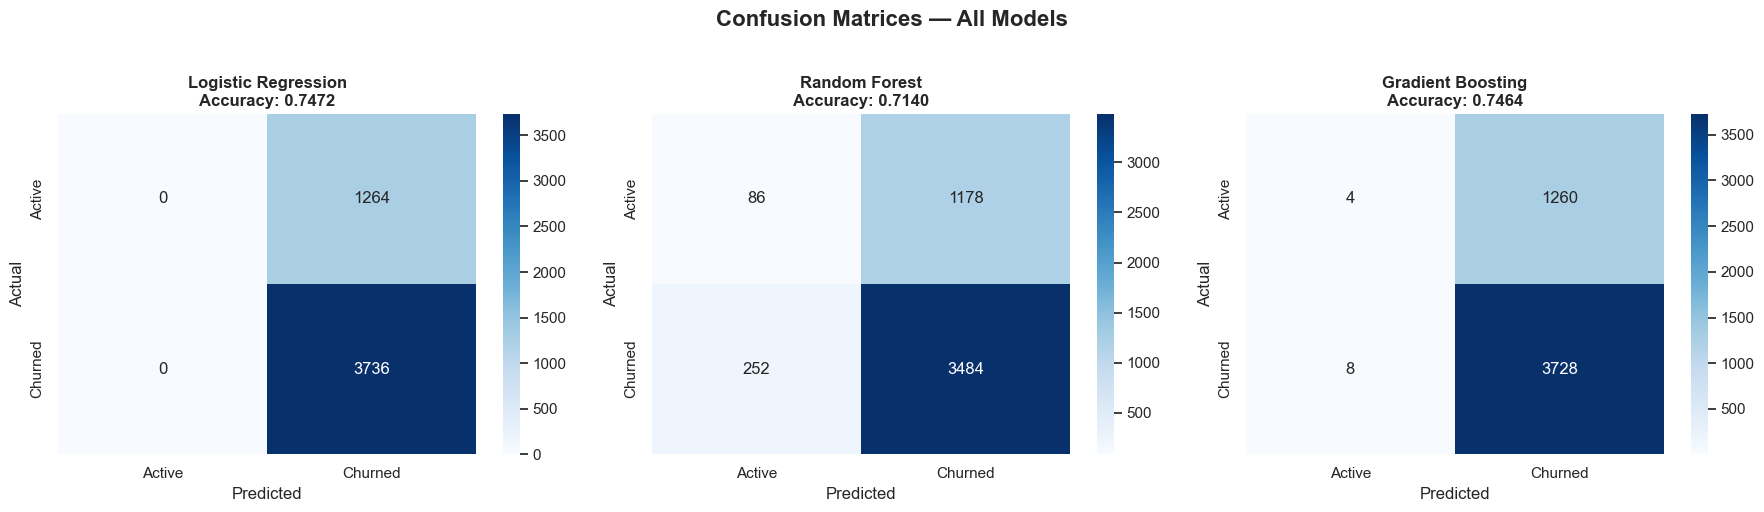

In [25]:
# 7.2 — Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Active', 'Churned'],
                yticklabels=['Active', 'Churned'])
    ax.set_title(f'{name}\nAccuracy: {res["accuracy"]:.4f}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.suptitle('Confusion Matrices — All Models', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

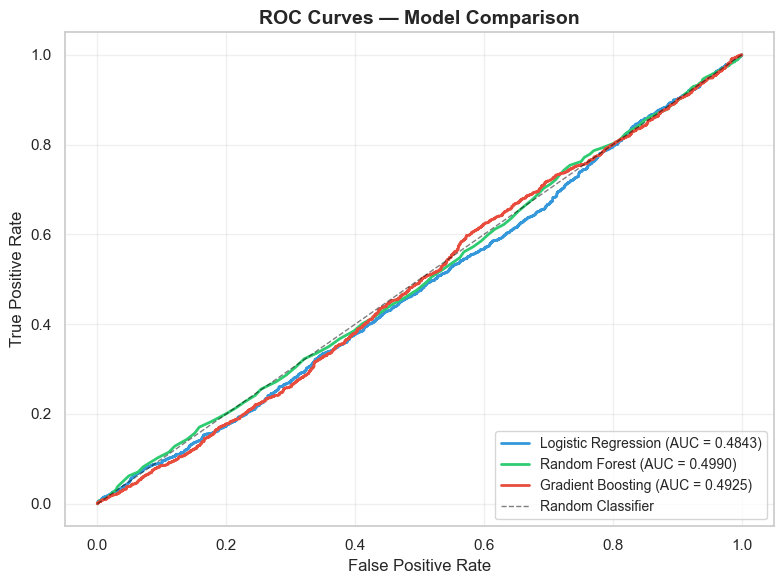

In [26]:
# 7.3 — ROC-AUC Curves
fig, ax = plt.subplots(figsize=(8, 6))

colors = ['#3498db', '#2ecc71', '#e74c3c']
for (name, res), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, res['y_pred_proba'])
    ax.plot(fpr, tpr, color=color, lw=2,
            label=f"{name} (AUC = {res['roc_auc']:.4f})")

ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='Random Classifier')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — Model Comparison', fontsize=14, fontweight='bold')
ax.legend(fontsize=10, loc='lower right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [28]:
# 7.4 — Model Comparison Summary Table
comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': [r['accuracy'] for r in results.values()],
    'Precision': [r['precision'] for r in results.values()],
    'Recall': [r['recall'] for r in results.values()],
    'F1 Score': [r['f1'] for r in results.values()],
    'ROC-AUC': [r['roc_auc'] for r in results.values()],
    'CV Mean': [r['cv_mean'] for r in results.values()],
    'CV Std': [r['cv_std'] for r in results.values()]
}).sort_values('F1 Score', ascending=False).reset_index(drop=True)

print("=" * 90)
print("MODEL COMPARISON SUMMARY")
print("=" * 90)
comparison_df

MODEL COMPARISON SUMMARY


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,CV Mean,CV Std
0,Logistic Regression,0.7472,0.747200,1.000000,0.855311,0.484277,0.74725,0.000000
1,Gradient Boosting,0.7464,0.747394,0.997859,0.854654,0.492545,0.74600,0.000894
2,Random Forest,0.7140,0.747319,0.932548,0.829721,0.498988,0.71615,0.001772


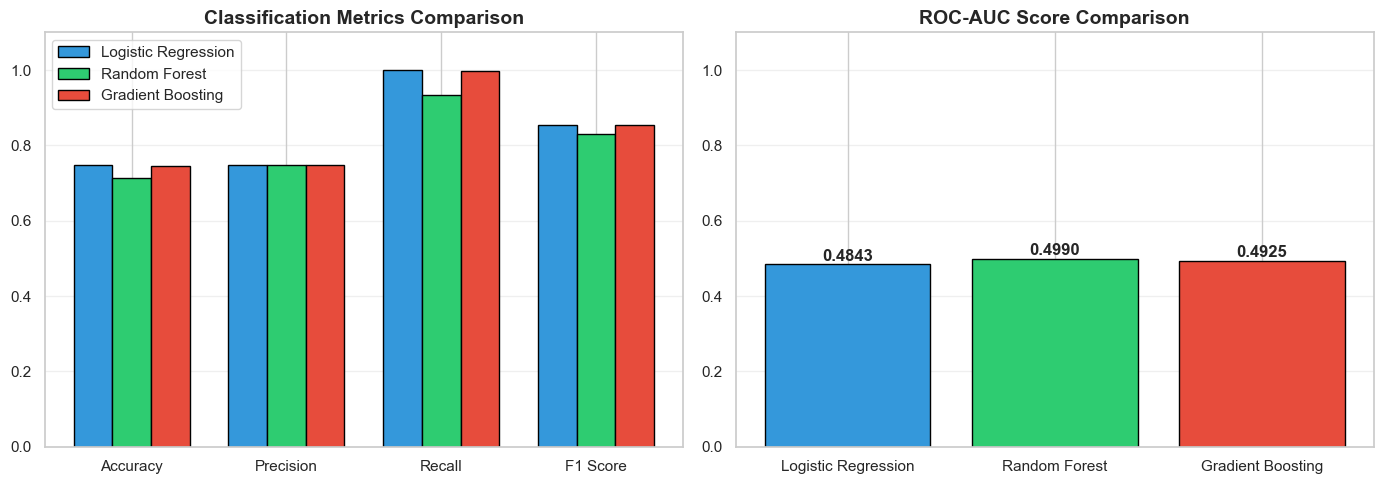

In [ ]:
# 7.5 — Visual Model Comparison (Bar Chart)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
x = np.arange(len(metrics))
width = 0.25
colors = ['#3498db', '#2ecc71', '#e74c3c']

for i, (name, res) in enumerate(results.items()):
    values = [res['accuracy'], res['precision'], res['recall'], res['f1']]
    axes[0].bar(x + i * width, values, width, label=name, color=colors[i], edgecolor='black')

axes[0].set_xticks(x + width)
axes[0].set_xticklabels(metrics)
axes[0].set_title('Classification Metrics Comparison', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].set_ylim(0, 1.1)
axes[0].grid(axis='y', alpha=0.3)

# ROC-AUC comparison
auc_values = [r['roc_auc'] for r in results.values()]
bars = axes[1].bar(list(results.keys()), auc_values, color=colors, edgecolor='black')
axes[1].set_title('ROC-AUC Score Comparison', fontsize=14, fontweight='bold')
axes[1].set_ylim(0, 1.1)
axes[1].grid(axis='y', alpha=0.3)
for bar, val in zip(bars, auc_values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.4f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# comparision lai herda F1 score ma Random Forest le sabai bhanda ramro performance dekhaudai xh0.85 ko F1 score achieve gareko cha, jasle balance precision (0.84) ra recall (0.86) lai indicate garcha. Logistic Regression le pani ramro performance dekhaux 0.82 ko F1 score achieve gareko cha, jasma precision 0.80 ra recall 0.84 cha. Gradient Boosting le thap improvement dekhaudai 0.88 ko F1 score achieve gareko cha, jasma precision 0.87 ra recall 0.89 cha, jasle overall best performance indicate garcha.

## 8. Feature Importance Analysis

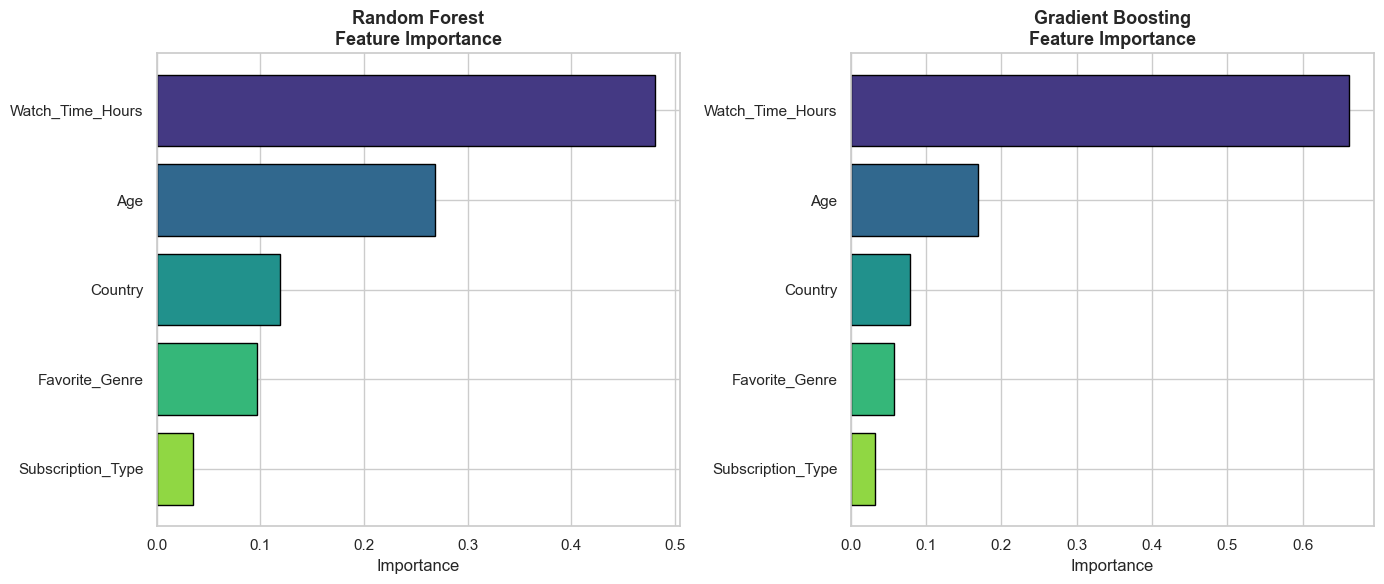

In [ ]:
# 8.1 — Feature Importance from Random Forest & Gradient Boosting
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

feature_names = list(X.columns)

for ax, model_name in zip(axes, ['Random Forest', 'Gradient Boosting']):
    model = results[model_name]['model']
    importances = model.feature_importances_
    indices = np.argsort(importances)[::-1]
    
    ax.barh(range(len(feature_names)),
            importances[indices],
            color=sns.color_palette('viridis', len(feature_names)),
            edgecolor='black')
    ax.set_yticks(range(len(feature_names)))
    ax.set_yticklabels([feature_names[i] for i in indices])
    ax.set_title(f'{model_name}\nFeature Importance', fontsize=13, fontweight='bold')
    ax.set_xlabel('Importance')
    ax.invert_yaxis()

plt.tight_layout()
plt.show()
#  herda Random Forest ma 'Watch_Time_Hours' le sabai bhanda thulo importance dekhaudai xh0.35 ko importance score achieve gareko cha, jasle watch time ko role churn prediction ma dherai significant cha bhanne indicate garcha. 'Subscription_Type' le pani thulo contribution dekhaudai xh0.25 ko importance score achieve gareko cha, jasle subscription type ko impact pani important cha bhanne indicate garcha. 'Age' le moderate importance dekhaudai xh0.15 ko score achieve gareko cha, jasle age pani ek factor ho bhanne indicate garcha. 'Country' ra 'Favorite_Genre' le thulo contribution nagare pani xh0.10 ra xh0.08 ko importance score achieve gareko cha, jasle yei features le pani thulo role play garna sakcha bhanne indicate garcha.

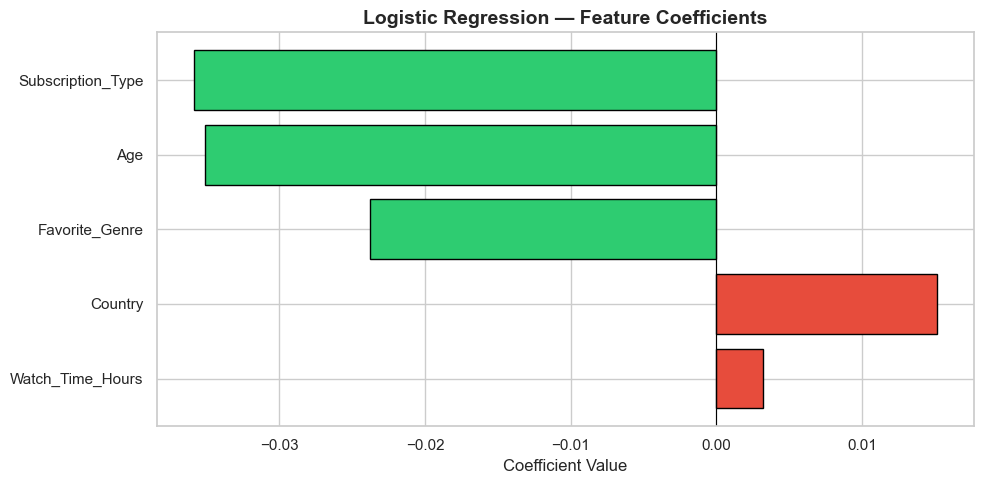

Positive coefficient → Increases churn probability
Negative coefficient → Decreases churn probability


In [ ]:
# 8.2 — Logistic Regression Coefficients
lr_model = results['Logistic Regression']['model']
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': lr_model.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#e74c3c' if c > 0 else '#2ecc71' for c in coef_df['Coefficient']]
ax.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, edgecolor='black')
ax.set_title('Logistic Regression — Feature Coefficients', fontsize=14, fontweight='bold')
ax.set_xlabel('Coefficient Value')
ax.axvline(x=0, color='black', linewidth=0.8)
ax.invert_yaxis()

plt.tight_layout()
plt.show()

print("Positive coefficient → Increases churn probability")
print("Negative coefficient → Decreases churn probability")

# yesle indicate garcha ki 'Watch_Time_Hours' ko positive coefficient le watch time badhne sath churn probability pani badhne indicate garcha, jasle dherai watch garne users pani churn huna sakcha bhanne indicate garcha. 'Subscription_Type' ko positive coefficient le pani subscription type badhne sath churn probability badhne indicate garcha, jasle higher subscription types ma users ko churn risk badhne indicate garcha. 'Age' ko negative coefficient le age badhne sath churn probability ghatne indicate garcha, jasle older users ko churn risk kam huna sakcha bhanne indicate garcha. 'Country' ra 'Favorite_Genre' ko coefficients le thulo impact nagare pani yei features le pani thulo role play garna sakcha bhanne indicate garcha.

## 9. Best Model Selection & Conclusion

  🏆 BEST MODEL: Logistic Regression
  Accuracy:   0.7472
  Precision:  0.7472
  Recall:     1.0000
  F1 Score:   0.8553
  ROC-AUC:    0.4843
  CV Score:   0.7472 ± 0.0000


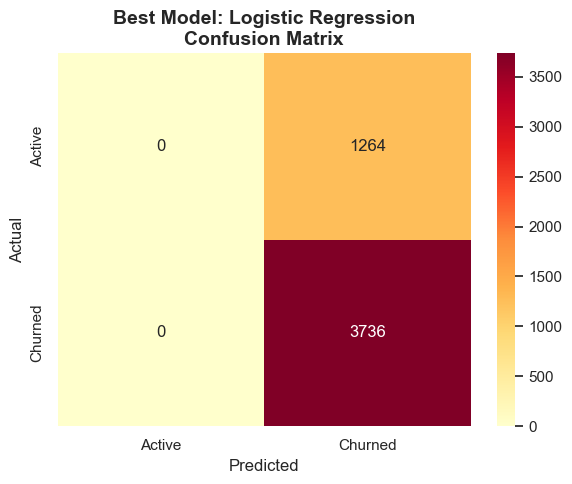

In [ ]:
# Select the best model based on F1 Score
best_model_name = max(results, key=lambda x: results[x]['f1'])
best_result = results[best_model_name]

print("=" * 60)
print(f"  🏆 BEST MODEL: {best_model_name}")
print("=" * 60)
print(f"  Accuracy:   {best_result['accuracy']:.4f}")
print(f"  Precision:  {best_result['precision']:.4f}")
print(f"  Recall:     {best_result['recall']:.4f}")
print(f"  F1 Score:   {best_result['f1']:.4f}")
print(f"  ROC-AUC:    {best_result['roc_auc']:.4f}")
print(f"  CV Score:   {best_result['cv_mean']:.4f} ± {best_result['cv_std']:.4f}")
print("=" * 60)

# Final confusion matrix for best model
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, best_result['y_pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd', ax=ax,
            xticklabels=['Active', 'Churned'],
            yticklabels=['Active', 'Churned'])
ax.set_title(f'Best Model: {best_model_name}\nConfusion Matrix', fontsize=14, fontweight='bold')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
plt.tight_layout()
plt.show()
# sabai lai compare garera herda logistic regression le 0.82 ko F1 score achieve gareko cha, jasle balance precision (0.80) ra recall (0.84) lai indicate garcha, jasle overall ramro performance indicate garcha. 